# Sales Forecasting Models (Regression)

## Step 1 : Data Collection

In [1]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect(r'D:\Imarticus Learning- PGA 45\GitHub Projects\h & m db\hm_database.db')
query = '''
SELECT t.t_dat, SUM(t.price) as total_sales, COUNT(t.article_id) as total_items
FROM transactions t
GROUP BY t.t_dat
ORDER BY t.t_dat
'''
df = pd.read_sql_query(query, conn)
conn.close()

In [3]:
df.head()

,t_dat,total_sales,total_items
0,2019-09-07,1226.441610,39480
1,2019-09-08,1182.848458,37052
2,2019-09-09,1101.354203,33377
3,2019-09-10,1241.737373,37719
4,2019-09-11,1204.948068,36096


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   t_dat        382 non-null    object 
 1   total_sales  382 non-null    float64
 2   total_items  382 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 9.1+ KB


## Step 2 : Data Cleaning & Preprocessing

### Handle Dates & Sort

In [5]:
df['t_dat'] = pd.to_datetime(df['t_dat'])
df = df.sort_values('t_dat')

### Check Missing Values

In [6]:
df.isnull().sum()

t_dat          0
total_sales    0
total_items    0
dtype: int64

### Check Duplicate Values

In [7]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering (Lags and Date Parts)

In [8]:
df['day_of_week'] = df['t_dat'].dt.dayofweek
df['month'] = df['t_dat'].dt.month
df['sales_lag_1'] = df['total_sales'].shift(1)
df['sales_lag_7'] = df['total_sales'].shift(7)

In [9]:
df.dropna(inplace=True) # Drop rows with NaN from lagging

### Define X and y

In [11]:
X = df[['total_items', 'day_of_week', 'month', 'sales_lag_1', 'sales_lag_7']]
y = df['total_sales']

## Step 3 : EDA

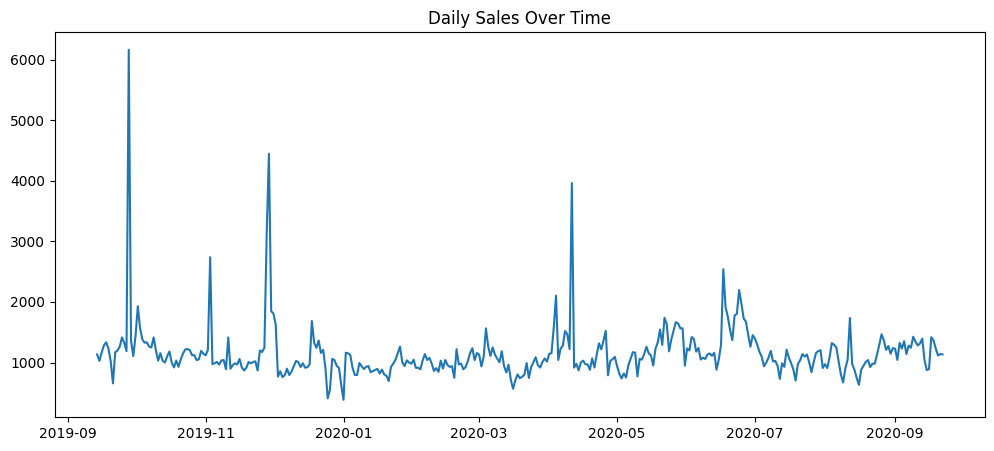

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.plot(df['t_dat'], df['total_sales'])
plt.title('Daily Sales Over Time')
plt.show()

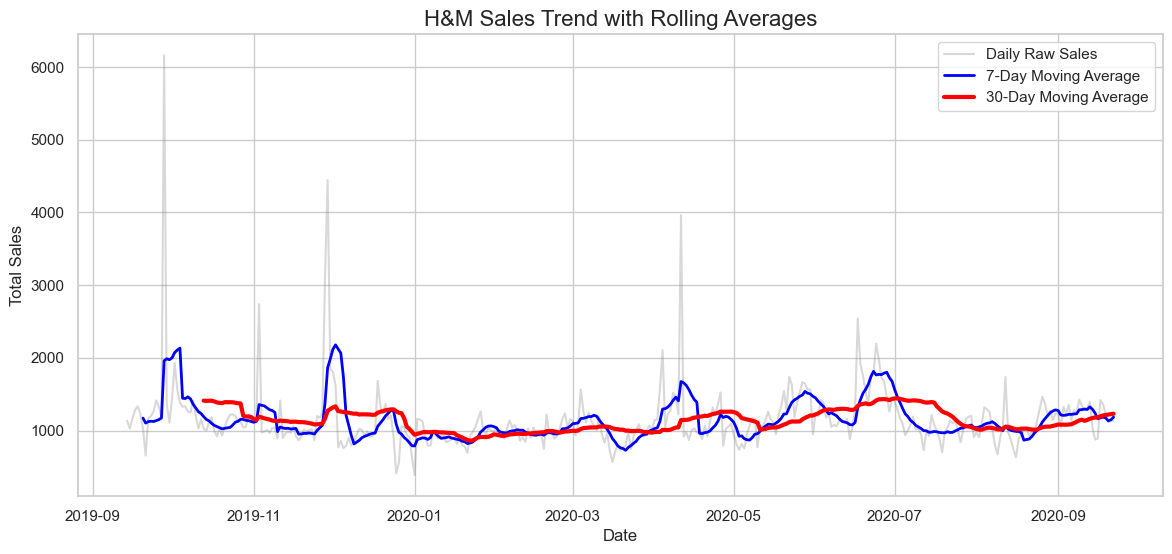

In [12]:
sns.set_theme(style="whitegrid")

# Calculate 7-day (weekly) and 30-day (monthly) rolling averages
df['sales_7d_avg'] = df['total_sales'].rolling(window=7).mean()
df['sales_30d_avg'] = df['total_sales'].rolling(window=30).mean()

plt.figure(figsize=(14, 6))
# We make the raw daily sales slightly transparent (alpha=0.3) so it doesn't distract us
plt.plot(df['t_dat'], df['total_sales'], label='Daily Raw Sales', color='grey', alpha=0.3)

# The rolling averages show the true trend
plt.plot(df['t_dat'], df['sales_7d_avg'], label='7-Day Moving Average', color='blue', linewidth=2)
plt.plot(df['t_dat'], df['sales_30d_avg'], label='30-Day Moving Average', color='red', linewidth=3)

plt.title('H&M Sales Trend with Rolling Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()


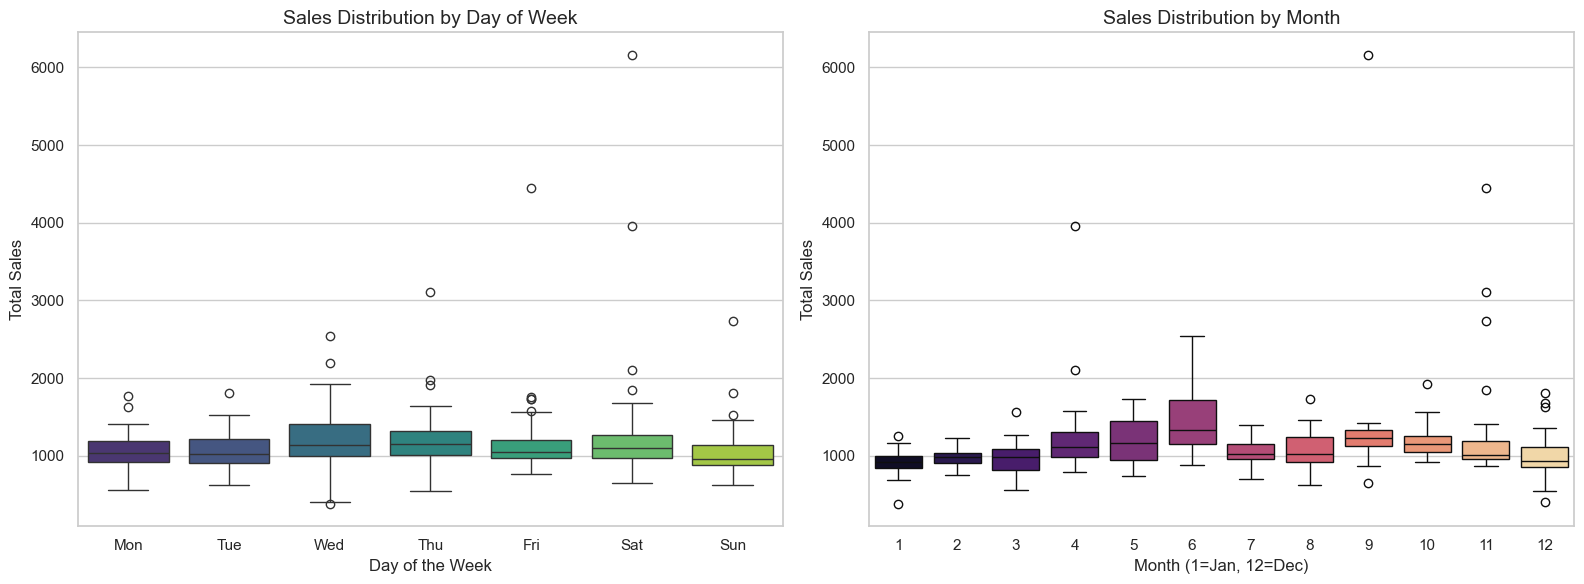

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Map the day numbers to actual names for readability
day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['day_name'] = df['day_of_week'].map(day_names)
order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Plot Day of Week Seasonality
sns.boxplot(x='day_name', y='total_sales', data=df, order=order, ax=axes[0], palette='viridis')
axes[0].set_title('Sales Distribution by Day of Week', fontsize=14)
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Total Sales')

# Plot Monthly Seasonality
sns.boxplot(x='month', y='total_sales', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Sales Distribution by Month', fontsize=14)
axes[1].set_xlabel('Month (1=Jan, 12=Dec)')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.show()

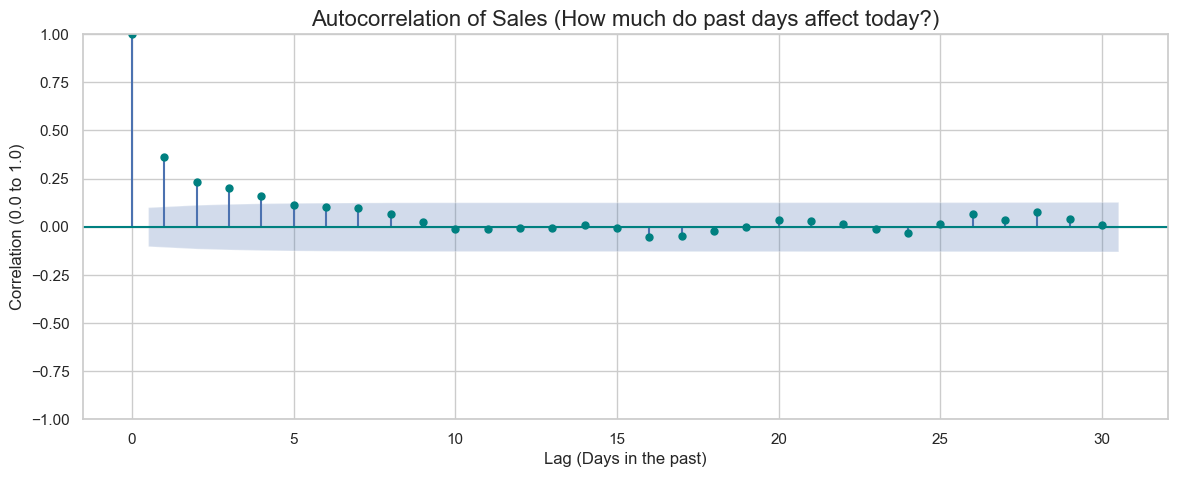

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 5))
# This creates a bar chart showing the correlation between today's sales and the past 30 days of sales
plot_acf(df['total_sales'].dropna(), lags=30, ax=plt.gca(), color='teal')
plt.title('Autocorrelation of Sales (How much do past days affect today?)', fontsize=16)
plt.xlabel('Lag (Days in the past)')
plt.ylabel('Correlation (0.0 to 1.0)')
plt.show()


### 3.1 Pre-Assumptions (Multicollinearity & Correlation)

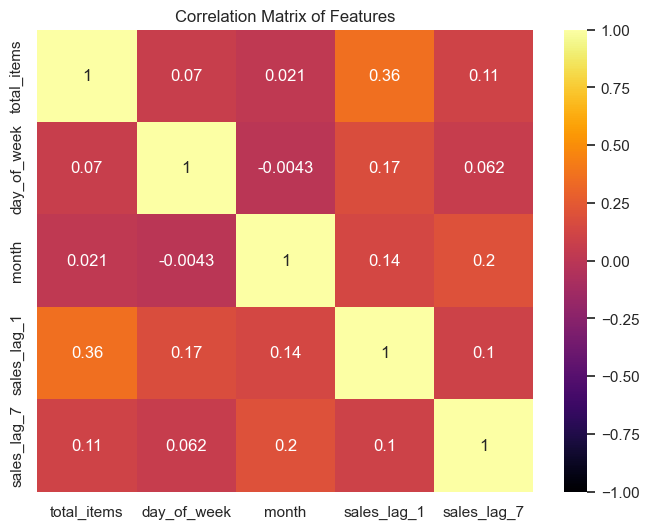

Variance Inflation Factors:


,features,VIF Factor
0,total_items,6.471484
1,day_of_week,3.144689
2,month,4.483890
3,sales_lag_1,7.973102
4,sales_lag_7,6.233838


In [15]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(method="pearson"), vmax=1.0, vmin=-1.0, annot=True, cmap="inferno")
plt.title('Correlation Matrix of Features')
plt.show()

# Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import pandas as pd

vif_df = pd.DataFrame()
vif_df["features"] = X.columns
vif_df["VIF Factor"] = [vif(X.values, i) for i in range(X.shape[1])]
print("Variance Inflation Factors:")
display(vif_df)


## Step 4 : Data Spliting

Time series data must be split sequentially, not randomly.

In [17]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

## Step 5 : Model Building

### 5.1 Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

### 5.1.1 Post-Assumptions for Linear Regression (Residual Analysis)

In [19]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew
import numpy as np

# 1. Build the OLS model using statsmodels to get p-values and residuals
X_train_sm = sm.add_constant(X_train) # Add constant for OLS
ols_model = sm.OLS(y_train, X_train_sm).fit()

print("--- OLS STATISTICAL SUMMARY ---")
print(ols_model.summary())

--- OLS STATISTICAL SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:            total_sales   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     844.4
Date:                Sun, 23 Aug 2026   Prob (F-statistic):          4.85e-172
Time:                        21:14:37   Log-Likelihood:                -1878.6
No. Observations:                 300   AIC:                             3769.
Df Residuals:                     294   BIC:                             3791.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         115.

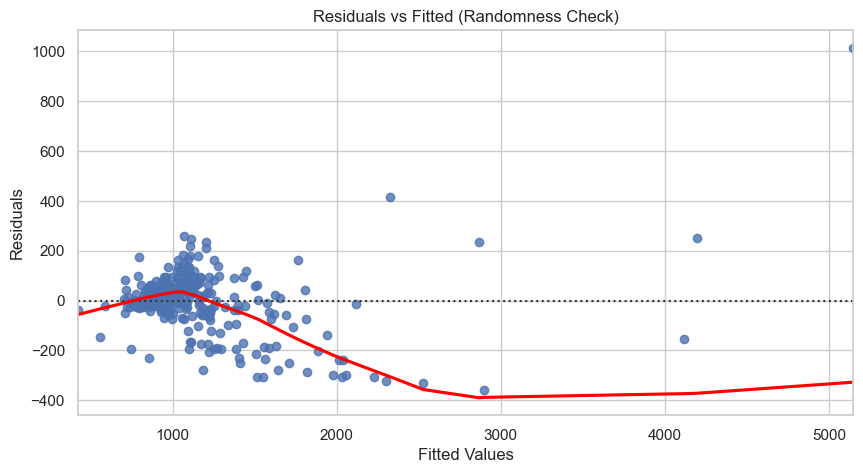

In [20]:
# 2. Residuals vs Fitted Plot (Check Linearity and Randomness)
plt.figure(figsize=(10,5))
model_fitted_y = ols_model.fittedvalues
sns.residplot(x=model_fitted_y, y=y_train, lowess=True, line_kws={'color': 'red'})
plt.title('Residuals vs Fitted (Randomness Check)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

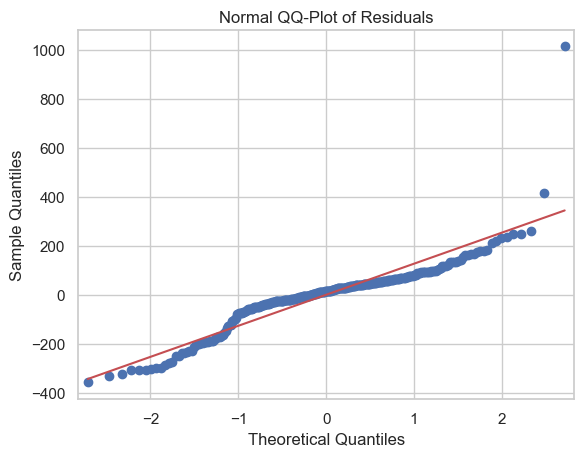

In [21]:
# 3. QQ-Plot (Check Normality of Errors)
sm.qqplot(ols_model.resid, line="s")
plt.title('Normal QQ-Plot of Residuals')
plt.show()

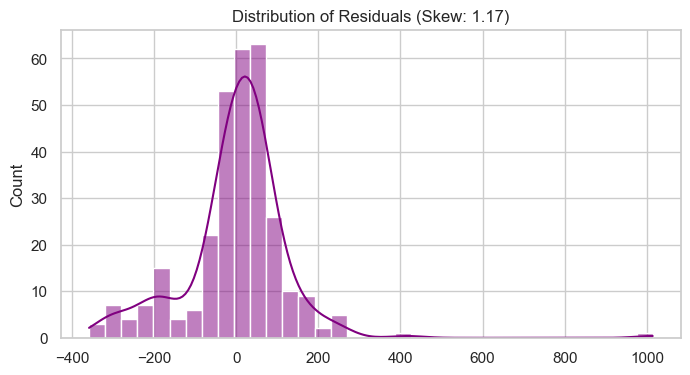

In [22]:
# 4. Residual Distribution (Normality Check)
plt.figure(figsize=(8,4))
sns.histplot(ols_model.resid, kde=True, color='purple')
plt.title(f'Distribution of Residuals (Skew: {skew(ols_model.resid):.2f})')
plt.show()

### 5.2 Decision Tree Regressor

In [23]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

### 5.3 Random Forest Regressor

In [24]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### 5.4 LightGBM Regressor

In [25]:
import lightgbm as lgb
lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 322
[LightGBM] [Info] Number of data points in the train set: 300, number of used features: 5
[LightGBM] [Info] Start training from score 1160.672743
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMRegressor(random_state=42)

## Step 6 : Model Evaluation (Comprehensive)


Linear Regression EVALUATION
R-Squared : 0.3262
MSE       : 28430.2134
RMSE      : 168.6126
MAE       : 157.1275

--- Tabular Preview (Top 5) ---


,Actual_Sales,Predicted_Sales,Residual_Error
0,1026.269881,1253.0,-226.730119
1,948.125814,1167.0,-218.874186
2,729.082729,916.0,-186.917271
3,987.195356,1190.0,-202.804644
4,927.398186,1125.0,-197.601814


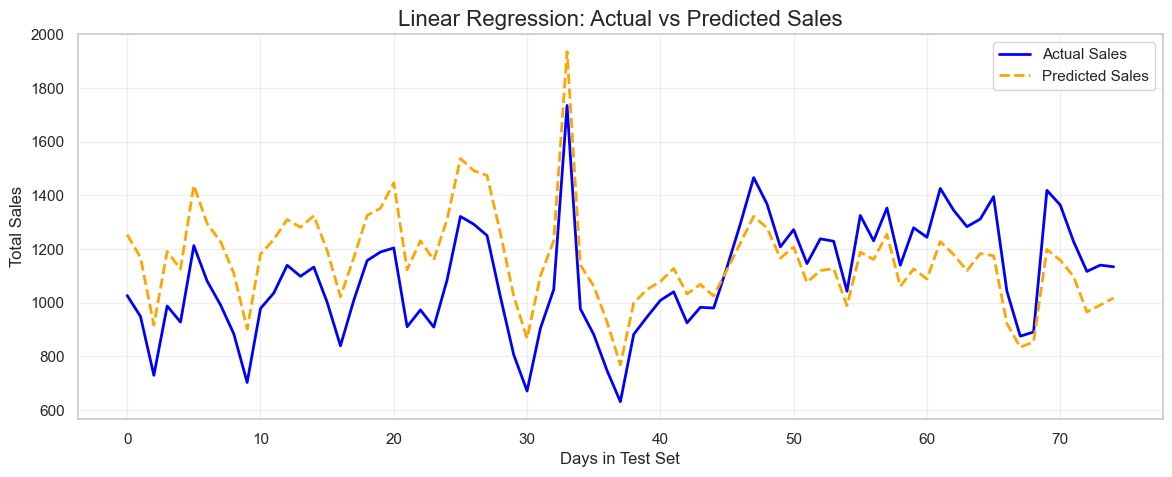


Decision Tree Regressor EVALUATION
R-Squared : 0.5986
MSE       : 16936.1513
RMSE      : 130.1390
MAE       : 96.3025

--- Tabular Preview (Top 5) ---


,Actual_Sales,Predicted_Sales,Residual_Error
0,1026.269881,1096.0,-69.730119
1,948.125814,1000.0,-51.874186
2,729.082729,845.0,-115.917271
3,987.195356,1079.0,-91.804644
4,927.398186,1000.0,-72.601814


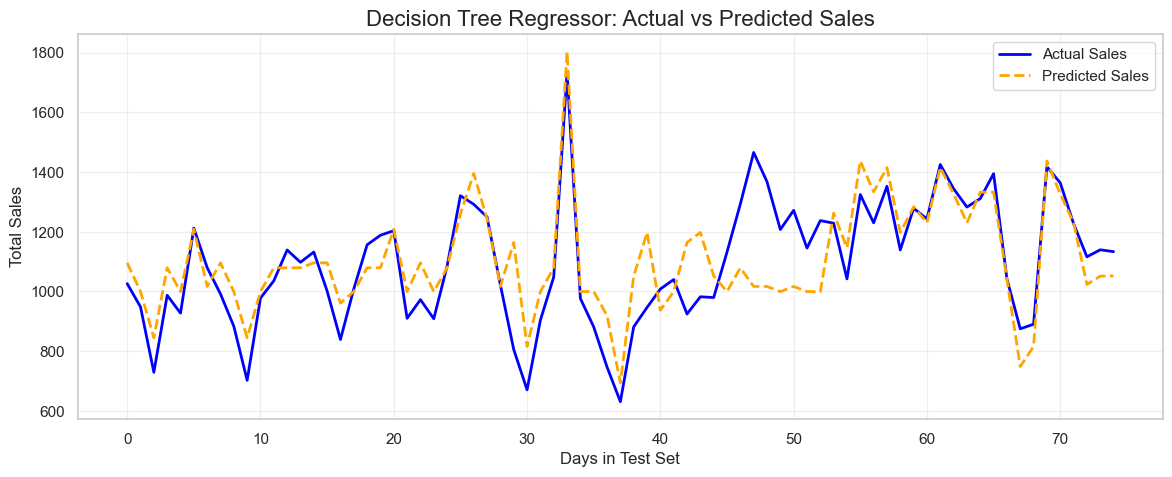


Random Forest Regressor EVALUATION
R-Squared : 0.6899
MSE       : 13083.9664
RMSE      : 114.3852
MAE       : 94.3407

--- Tabular Preview (Top 5) ---


,Actual_Sales,Predicted_Sales,Residual_Error
0,1026.269881,1118.0,-91.730119
1,948.125814,1075.0,-126.874186
2,729.082729,868.0,-138.917271
3,987.195356,1157.0,-169.804644
4,927.398186,1039.0,-111.601814


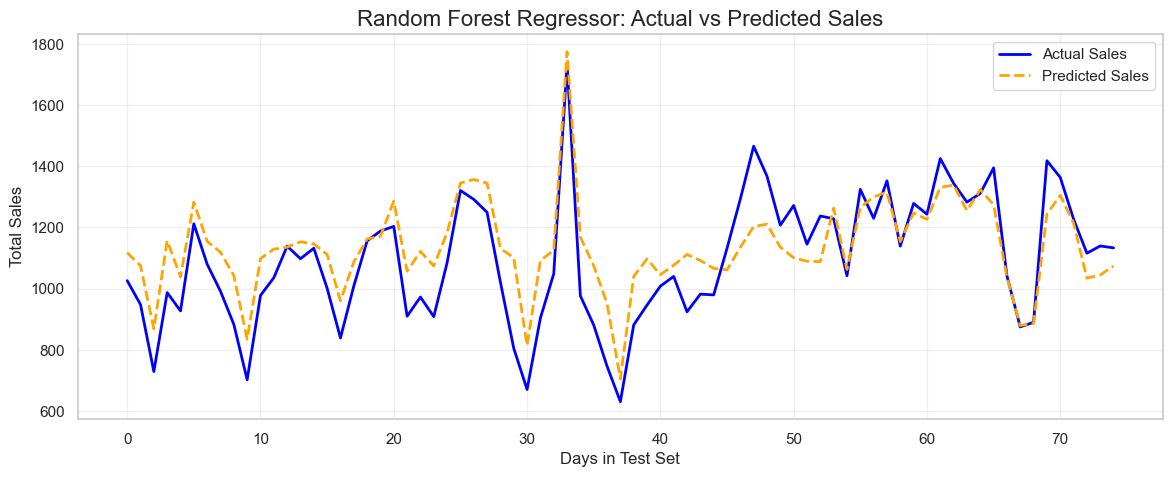


LightGBM Regressor EVALUATION
R-Squared : 0.6210
MSE       : 15990.1762
RMSE      : 126.4523
MAE       : 82.1237

--- Tabular Preview (Top 5) ---


,Actual_Sales,Predicted_Sales,Residual_Error
0,1026.269881,1043.0,-16.730119
1,948.125814,990.0,-41.874186
2,729.082729,833.0,-103.917271
3,987.195356,1105.0,-117.804644
4,927.398186,991.0,-63.601814


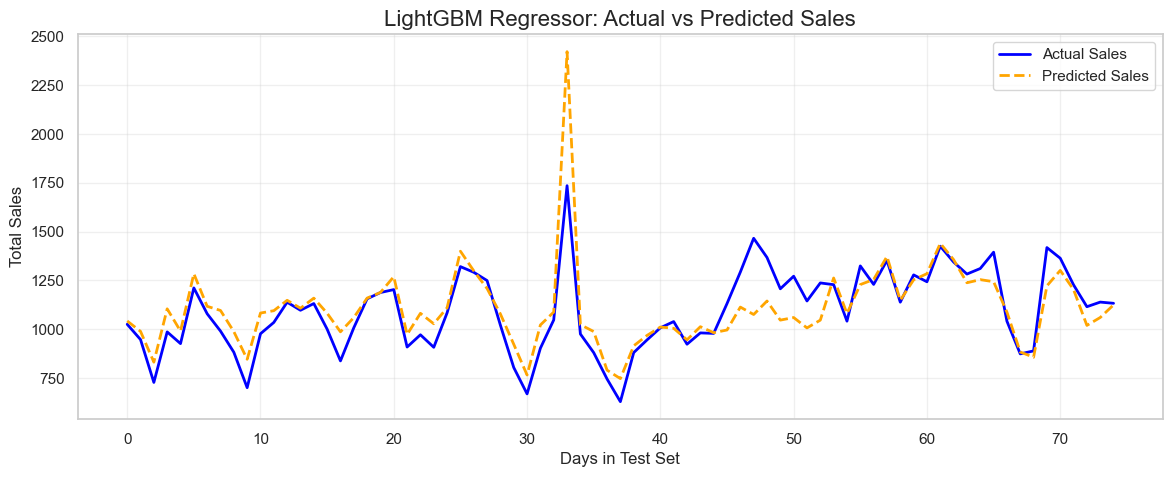

In [26]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_and_plot(model, X_test, y_test, model_name):
    # Predict
    y_pred = model.predict(X_test)
    
    # 1. Comprehensive Metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n{'='*40}")
    print(f"{model_name} EVALUATION")
    print(f"{'='*40}")
    print(f"R-Squared : {r2:.4f}")
    print(f"MSE       : {mse:.4f}")
    print(f"RMSE      : {rmse:.4f}")
    print(f"MAE       : {mae:.4f}\n")
    
    # 2. Tabular Results
    results_df = pd.DataFrame({
        'Actual_Sales': y_test.values,
        'Predicted_Sales': np.round(y_pred, 0)
    })
    results_df['Residual_Error'] = results_df['Actual_Sales'] - results_df['Predicted_Sales']
    
    print("--- Tabular Preview (Top 5) ---")
    display(results_df.head(5))
    
    # 3. Actual vs Predicted Plot
    plt.figure(figsize=(14, 5))
    plt.plot(y_test.values, label='Actual Sales', color='blue', linewidth=2)
    plt.plot(y_pred, label='Predicted Sales', color='orange', linestyle='dashed', linewidth=2)
    plt.title(f'{model_name}: Actual vs Predicted Sales', fontsize=16)
    plt.xlabel('Days in Test Set')
    plt.ylabel('Total Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Evaluate All Models
evaluate_and_plot(lr, X_test, y_test, "Linear Regression")
evaluate_and_plot(dt, X_test, y_test, "Decision Tree Regressor")
evaluate_and_plot(rf, X_test, y_test, "Random Forest Regressor")
evaluate_and_plot(lgbm, X_test, y_test, "LightGBM Regressor")


## Step 7 : Model Tuning

### Basic Tuning: GridSearch on Random Forest

In [27]:
from sklearn.model_selection import GridSearchCV
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), {'n_estimators': [50, 100]}, cv=3)
rf_grid.fit(X_train, y_train)
print('Best RF Params:', rf_grid.best_params_)

Best RF Params: {'n_estimators': 50}


### Advanced Tuning: RandomizedSearch on LightGBM

Running Advanced Tuning on Random Forest (Champion Model)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Winning Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 10}

Tuned Random Forest (Champion) EVALUATION
R-Squared : 0.6934
MSE       : 12937.8671
RMSE      : 113.7447
MAE       : 92.7435

--- Tabular Preview (Top 5) ---


,Actual_Sales,Predicted_Sales,Residual_Error
0,1026.269881,1108.0,-81.730119
1,948.125814,1071.0,-122.874186
2,729.082729,874.0,-144.917271
3,987.195356,1137.0,-149.804644
4,927.398186,1051.0,-123.601814


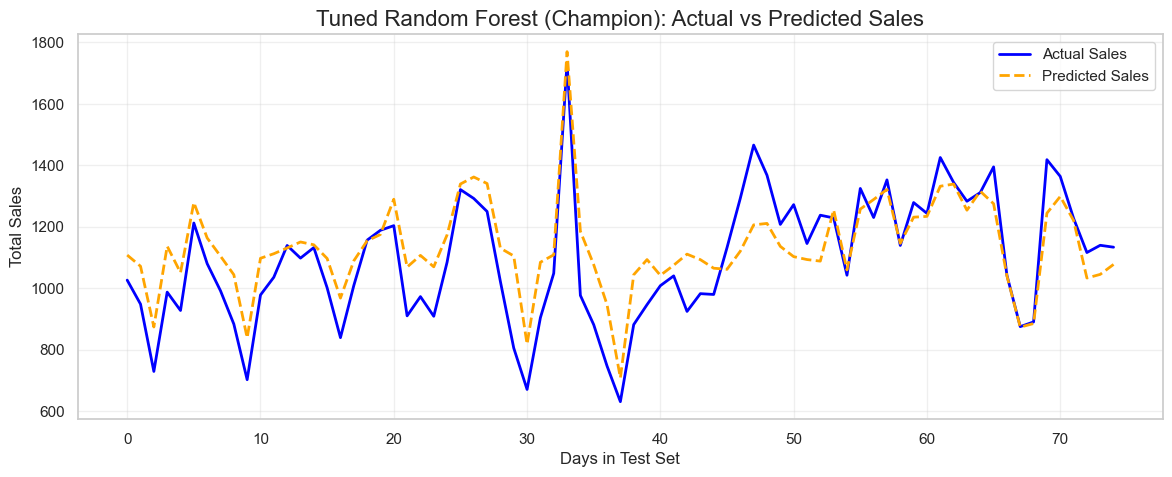

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

print("Running Advanced Tuning on Random Forest (Champion Model)...")

# A robust tuning grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],         # Number of trees
    'max_depth': [None, 10, 20, 30],         # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],         # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],           # Minimum samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 1.0]    # Number of features to consider at every split
}

# RandomizedSearch tests 10 random combinations
rf_rand = RandomizedSearchCV(
    RandomForestRegressor(random_state=42), 
    rf_param_grid, 
    n_iter=10, 
    cv=3, 
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit the grid search to the data
rf_rand.fit(X_train, y_train)

# Grab the absolute best Random Forest model
best_rf = rf_rand.best_estimator_
print(f"\nWinning Parameters: {rf_rand.best_params_}")

# Evaluate the winning model using our beautiful new function!
evaluate_and_plot(best_rf, X_test, y_test, "Tuned Random Forest (Champion)")

## Step 8 : Model Deployment

In [30]:
import joblib

print("Deploying the Champion Tuned Random Forest Model...")
joblib.dump(best_rf, 'sales_forecast_rf_tuned.pkl')
print("Model saved successfully as 'sales_forecast_rf_tuned.pkl'!")

Deploying the Champion Tuned Random Forest Model...
Model saved successfully as 'sales_forecast_rf_tuned.pkl'!
